In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import os
os.listdir("../data/raw")

['cars_dataset.csv']

### Load Dataset

In [3]:
df = pd.read_csv("../data/raw/cars_dataset.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


### Data Understanding

In [4]:
df.shape

(72435, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(3), int64(3), str(4)
memory usage: 5.5 MB


In [6]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16580.158708,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.028754,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,495.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


In [7]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

### Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(842)

In [9]:
df[df.duplicated()]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
273,Q3,2019,34485,Automatic,10,Diesel,145.0,47.1,2.0,audi
764,Q2,2019,22495,Manual,1000,Diesel,145.0,49.6,1.6,audi
784,Q3,2015,13995,Manual,35446,Diesel,145.0,54.3,2.0,audi
967,Q5,2019,31998,Semi-Auto,100,Petrol,145.0,33.2,2.0,audi
990,Q2,2019,22495,Manual,1000,Diesel,145.0,49.6,1.6,audi
...,...,...,...,...,...,...,...,...,...,...
71802,Santa Fe,2019,32995,Semi-Auto,30,Diesel,145.0,40.9,2.2,Hyundai
71952,Tucson,2016,10991,Manual,108000,Diesel,125.0,58.9,2.0,Hyundai
71954,I30,2015,4492,Manual,124000,Diesel,0.0,78.4,1.6,Hyundai
72416,I40,2017,11485,Manual,17393,Diesel,145.0,65.7,1.7,Hyundai


In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.nunique()

model             146
year               25
price           10418
transmission        4
mileage         35743
fuelType            5
tax                47
mpg               177
engineSize         32
Make                7
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

### Separate Numerical & Categorical Columns

In [13]:
# Numerical Columns
num_columns = df.select_dtypes(include="number").columns
num_columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

In [14]:
# Categorical Columns
cat_columns = df.select_dtypes(include=["object", "string"]).columns
cat_columns

Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')

## Explorary data Analysis(EDA)

### For Numerical COlumns

### Distribution and Boxplot of Car Price 

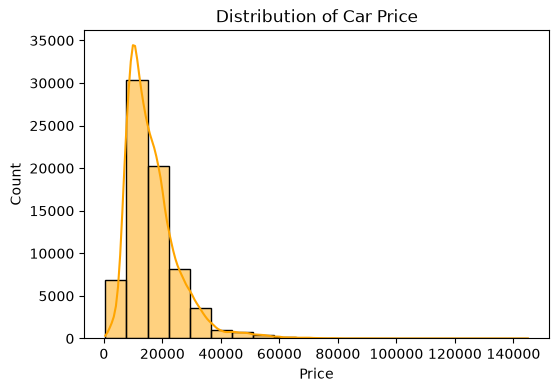

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="price", kde=True,color = "orange", bins =20)
plt.title("Distribution of Car Price")
plt.xlabel("Price")
plt.savefig("../images/price_distribution.png", dpi =300)

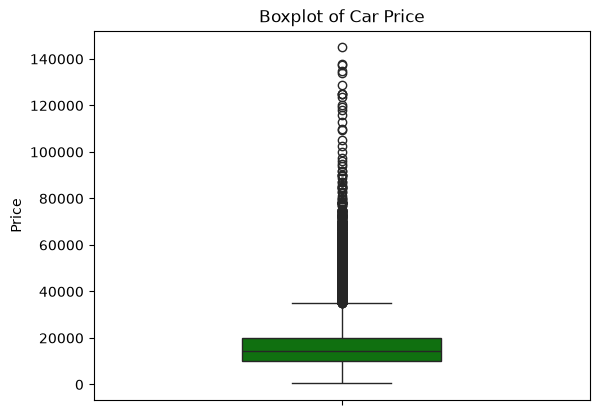

In [16]:
sns.boxplot(data=df, y="price", color="green", width=0.4)
plt.title("Boxplot of Car Price")
plt.ylabel("Price")
plt.savefig("../images/car_price_Distribution.png", dpi =300)

### Distribution and Boxplot of Mileage

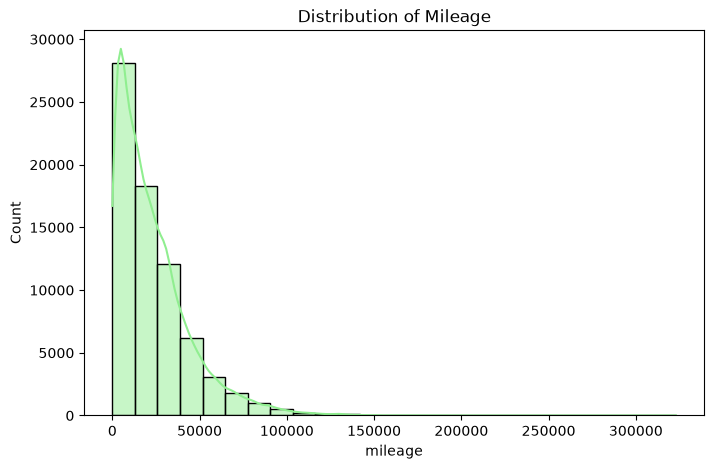

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="mileage",bins = 25,color ="lightgreen", kde=True)
plt.title("Distribution of Mileage")
plt.savefig("../images/mileage_distribution.png", dpi =300)

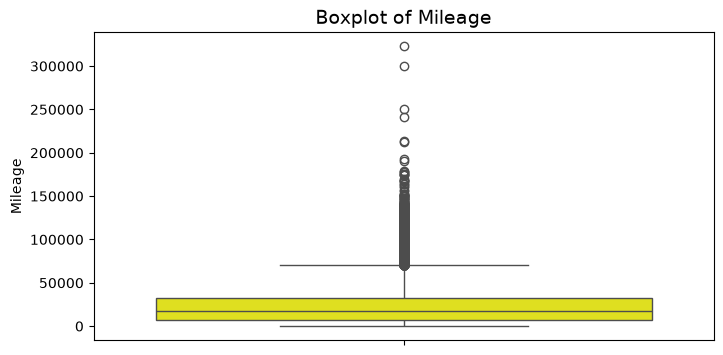

In [18]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, y="mileage", color="yellow")
plt.title("Boxplot of Mileage", fontsize=14)
plt.ylabel("Mileage")
plt.savefig("../images/Boxplot_Mileage.png", dpi =300)

### Distribution and boxplot of Engine size

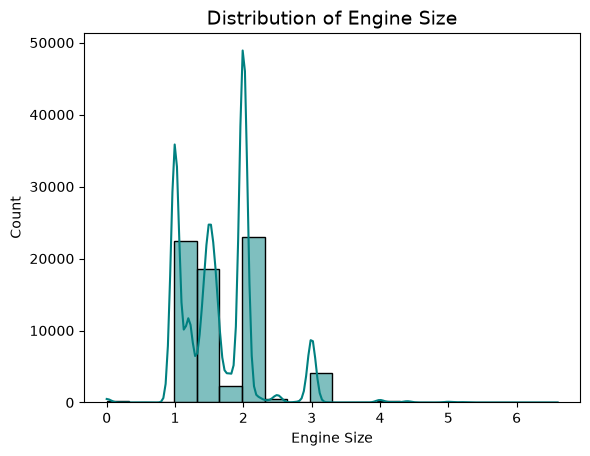

In [19]:
sns.histplot(data = df, x = "engineSize", bins = 20, kde=True, color="teal", stat="count")
plt.title("Distribution of Engine Size", fontsize=14)
plt.xlabel("Engine Size")
plt.savefig("../images/Engine_size_Distribution.png", dpi =300)

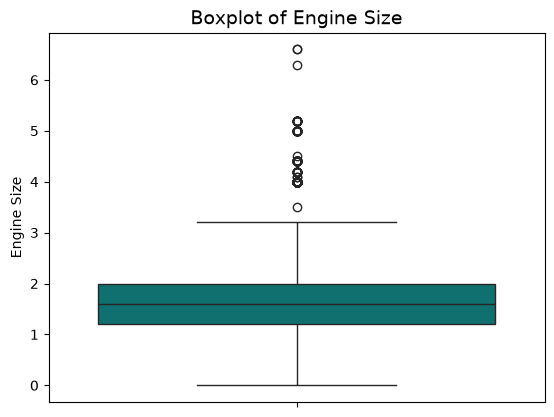

In [20]:
sns.boxplot( data=df,y="engineSize", color="teal")
plt.title("Boxplot of Engine Size", fontsize=14)
plt.ylabel("Engine Size")
plt.savefig("../images/Engine_Size_Boxplot.png", dpi =300)

### Fuel Type Countplot

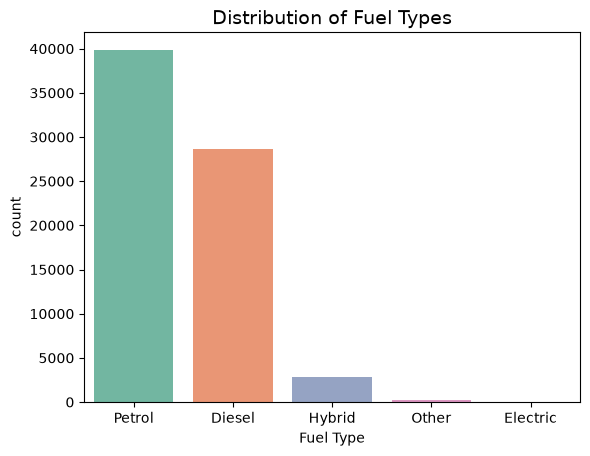

In [21]:
sns.countplot(data=df, x="fuelType", hue ="fuelType", palette="Set2")
plt.title("Distribution of Fuel Types", fontsize=14)
plt.xlabel("Fuel Type")
plt.savefig("../images/Fuel_Types_distribution.png", dpi =300)

### Make CountPlot

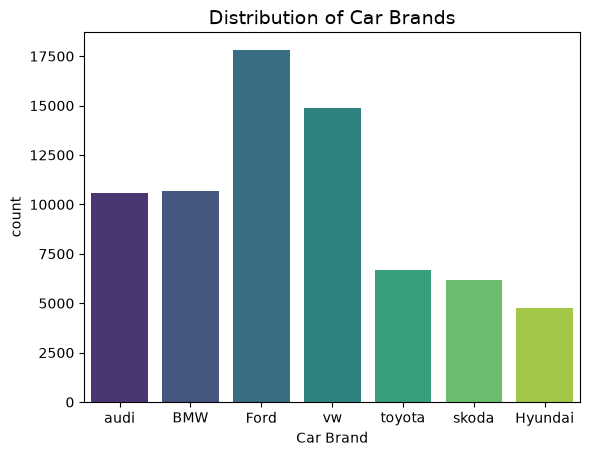

In [22]:
sns.countplot(data=df, x="Make", hue="Make", palette="viridis")
plt.title("Distribution of Car Brands", fontsize=14)
plt.xlabel("Car Brand")
plt.savefig("../images/Car_Brands_Distribution.png", dpi =300)

### Relationship between Features and Target

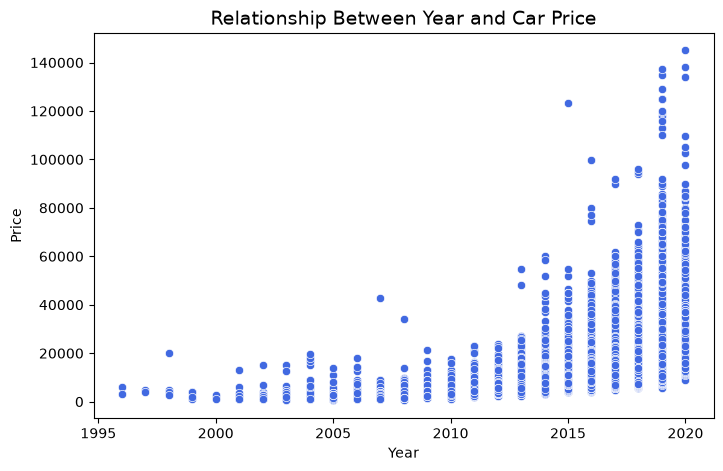

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x= "year", y="price",color="royalblue")
plt.title("Relationship Between Year and Car Price", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Price")
plt.savefig("../images/Year_VS_Car_price.png", dpi =300)

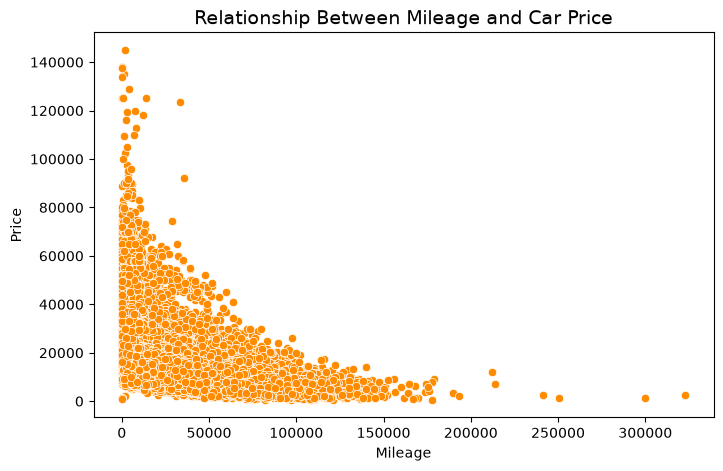

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x="mileage", y="price", color="darkorange")
plt.title("Relationship Between Mileage and Car Price", fontsize=14)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.savefig("../images/Mileage_VS_Car_price.png", dpi =300)

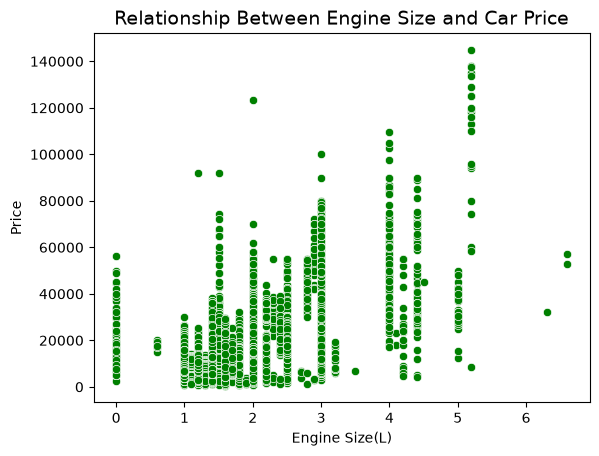

In [25]:
sns.scatterplot(data=df,x = "engineSize", y="price", color="green")
plt.title("Relationship Between Engine Size and Car Price", fontsize=14)
plt.xlabel("Engine Size(L)")
plt.ylabel("Price")
plt.savefig("../images/Engine_Size_VS_Car_Price.png", dpi = 300)

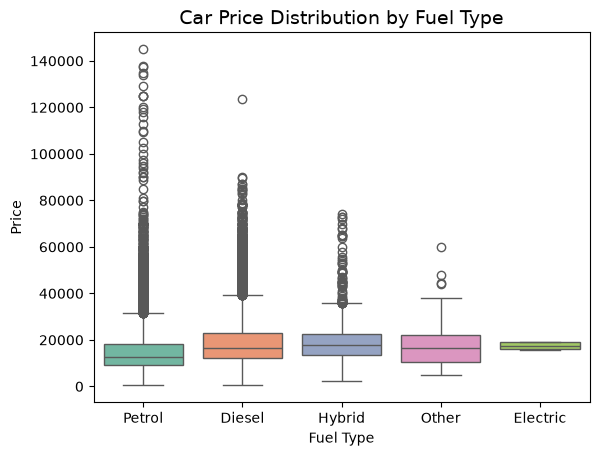

In [26]:
sns.boxplot(data=df, x="fuelType", y="price", hue="fuelType", palette="Set2")
plt.title("Car Price Distribution by Fuel Type", fontsize=14)
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.savefig("../images/Fuel_type_VS_Car_Price.png", dpi = 300)

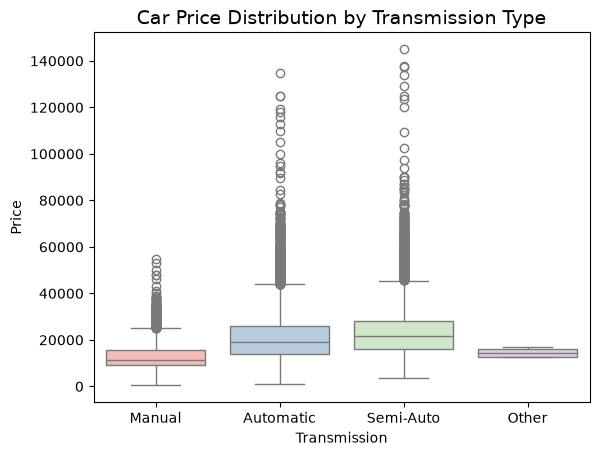

In [27]:
sns.boxplot(data = df, x = "transmission", y = "price", hue = "transmission", palette = "Pastel1")
plt.title("Car Price Distribution by Transmission Type", fontsize=14)
plt.xlabel("Transmission")
plt.ylabel("Price")
plt.savefig("../images/Transmision_Type_VS_Car_Price.png", dpi = 300)

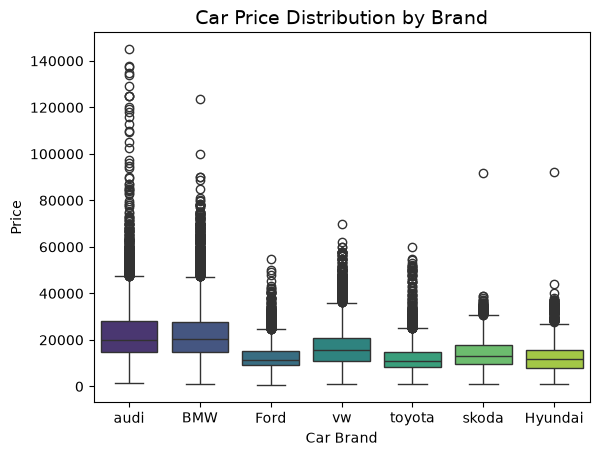

In [28]:
sns.boxplot( data = df, x = "Make", y = "price", hue = "Make", palette = "viridis")
plt.title("Car Price Distribution by Brand", fontsize = 14)
plt.xlabel("Car Brand")
plt.ylabel("Price")
plt.savefig("../images/Brand_VS_Car_Price.png", dpi = 300)

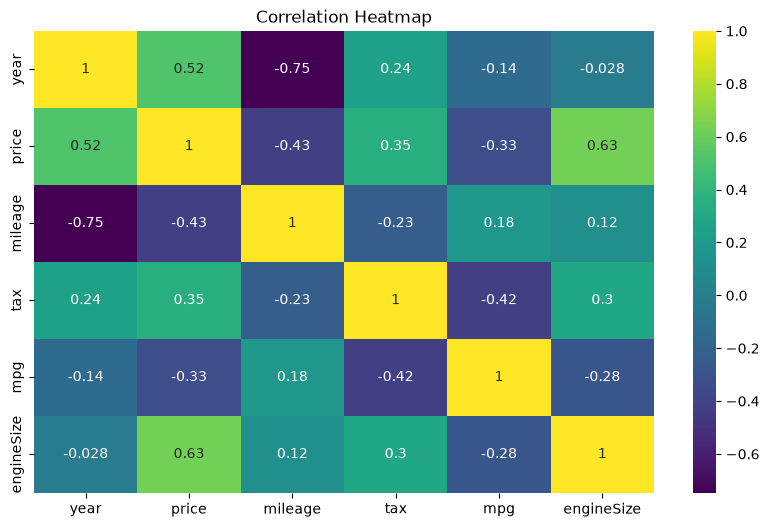

In [29]:
## Correlation heatmap 

plt.figure(figsize =(10, 6))
sns.heatmap(data = df.corr(numeric_only =True), annot = True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.savefig("../images/Correlation_Heatmap.png", dpi = 300)

In [30]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


### Separate feature and target

In [31]:
x = df.drop("price", axis=1)
y = df["price"]

In [32]:
x.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,Manual,1998,Petrol,145.0,49.6,1.0,audi


In [33]:
y.head()

0    12500
1    16500
2    11000
3    16800
4    17300
Name: price, dtype: int64

In [34]:
## numerical columns in dataset

num_columns = x.select_dtypes(include="number").columns
num_columns

Index(['year', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='str')

In [35]:
## Categorical columns 

cat_columns = x.select_dtypes(include = ["object", "str"]).columns
cat_columns

Index(['model', 'transmission', 'fuelType', 'Make'], dtype='str')

In [36]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi


### Train_Test_Split

In [37]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size =0.20, random_state = 42)

In [38]:
x_train.shape

(57274, 9)

In [39]:
x_test.shape

(14319, 9)

### Create Preprocessor

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers =[
        (
            "cat",
            OneHotEncoder(drop ="first", handle_unknown ="ignore"),
            cat_columns
        ),
        (
            "num",
            StandardScaler(),
            num_columns)
        ]
)

In [41]:
x_train = preprocessor.fit_transform(x_train)

In [42]:
x_test = preprocessor.transform(x_test)

In [43]:
x_train.shape

(57274, 163)

In [44]:
x_test.shape

(14319, 163)

In [45]:
type(x_train)

scipy.sparse._csr.csr_matrix

In [46]:
type(x_test)

scipy.sparse._csr.csr_matrix

In [47]:
preprocessor.get_feature_names_out()

array(['cat__model_ 2 Series', 'cat__model_ 3 Series',
       'cat__model_ 4 Series', 'cat__model_ 5 Series',
       'cat__model_ 6 Series', 'cat__model_ 7 Series',
       'cat__model_ 8 Series', 'cat__model_ A1', 'cat__model_ A2',
       'cat__model_ A3', 'cat__model_ A4', 'cat__model_ A5',
       'cat__model_ A6', 'cat__model_ A7', 'cat__model_ A8',
       'cat__model_ Accent', 'cat__model_ Amarok', 'cat__model_ Amica',
       'cat__model_ Arteon', 'cat__model_ Auris', 'cat__model_ Avensis',
       'cat__model_ Aygo', 'cat__model_ B-MAX', 'cat__model_ Beetle',
       'cat__model_ C-HR', 'cat__model_ C-MAX', 'cat__model_ CC',
       'cat__model_ Caddy', 'cat__model_ Caddy Life',
       'cat__model_ Caddy Maxi', 'cat__model_ Caddy Maxi Life',
       'cat__model_ California', 'cat__model_ Camry',
       'cat__model_ Caravelle', 'cat__model_ Citigo',
       'cat__model_ Corolla', 'cat__model_ EcoSport', 'cat__model_ Edge',
       'cat__model_ Eos', 'cat__model_ Escort', 'cat__model_ Fabi

### Linear Regression Model

In [48]:
model = LinearRegression()

In [49]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](163,)","[ 518.74, 2545.64, 2781.24,..., -655.29,-1436.83, 2455.32]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.595e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,163


In [50]:
model.coef_

array([ 5.18741466e+02,  2.54564148e+03,  2.78123644e+03,  4.47044184e+03,
        3.76845296e+03,  1.27362285e+04,  3.35617688e+04, -1.31869395e+04,
        1.44720511e+03, -1.10662330e+04, -1.01332374e+04, -8.39429474e+03,
       -7.95400008e+03, -5.95425472e+03, -1.82245133e+03,  1.04357685e+04,
        2.19814703e+03,  3.49341691e+03,  7.40801855e+02, -5.46302165e+03,
       -2.69985471e+03, -6.51796519e+03, -4.81878589e+03, -2.87122840e+03,
       -1.37662338e+03, -3.53209057e+03, -4.45435838e+03, -2.94981106e+03,
       -3.87688202e+03, -2.79767706e+03, -4.93797048e+03,  3.32944547e+04,
       -3.89111268e+03,  1.61584058e+04, -4.00569791e+03, -2.30372599e+03,
       -3.11002611e+03,  3.60375609e+03,  3.65332814e+02,  1.67761991e+04,
       -3.06144545e+03, -3.57718656e+03, -1.61978733e+03,  2.08568560e+03,
        2.74795398e+03, -4.57587292e+02,  1.89282105e+03,  6.80202818e+03,
       -2.99854229e+03, -4.85204878e+03, -3.11411229e+03, -5.63790830e+02,
        5.17939866e+02, -

In [51]:
model.intercept_

np.float64(15951.418093437083)

### Predict the model

In [52]:
y_pred = model.predict(x_test)

comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
33392,10500,12685.742844
71631,17995,19717.991858
19752,28488,25609.000033
52608,14000,13356.296180
64900,17495,18090.314498
6366,28895,27260.468960
35862,3990,-2591.352092
47619,11990,14399.893843
66802,8999,11111.277412
37865,8899,9508.427958


### Model Evaluation

In [53]:
mae = mean_absolute_error(y_test, y_pred)
mae

2073.394233359093

In [54]:
mse = mean_squared_error(y_test, y_pred)
mse

9851820.62825306

In [55]:
rmse = mean_squared_error(y_test, y_pred)**0.5
rmse

3138.761002091918

In [56]:
r2 = r2_score(y_test, y_pred)
r2

0.8878346668315708

### Now Save Model

In [57]:
import joblib

In [58]:
joblib.dump(model, "../models/used_car_price_predictor.pkl")

['../models/used_car_price_predictor.pkl']

In [60]:
## Load Model 

load_model = joblib.load("../models/used_car_price_predictor.pkl")

In [61]:
type(load_model)

sklearn.linear_model._base.LinearRegression